# Hyperliquid × Bitcoin Fear/Greed Index
### Trader Behavior & Performance Analysis - How Market Sentiment Drives Trader Behavior on Hyperliquid

# Recommendations

**Goal:** Translate data findings into two concrete, actionable strategy rules.
Every recommendation is tethered to a specific finding from the analysis.

Stakeholders care about one thing: **what should we do differently?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('clean_trades.csv', parse_dates=['date'])
close_df = df[df['is_close']].copy()
sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

---
## Strategy Rule 1 — Trade More Aggressively on Fear Days; Reduce Exposure on Extreme Greed\


**Rule:** *On Fear and Extreme Fear days, increase trade frequency and position size — these are the days this sample's traders outperform. On Extreme Greed days, reduce position size and consider short rather than long bias.*

**Evidence base:**
- Fear days produce median daily PnL of $13,527 vs Greed's $1,151 — an 11.7× difference (p<0.0001)
- Traders already go long on Fear (L/S ratio 2.21×) and short on Greed (0.73×) — the profitable traders in this sample ARE contrarians
- Trade size is 53% larger on Extreme Fear ($767) than Extreme Greed ($500) — sizing up into fear is already the observed behaviour

In [2]:
# Build the evidence table for Rule 1
trader_lev = df.groupby('trader_id')['leverage_proxy'].median()
lev_med = trader_lev.median()
high_lev = trader_lev[trader_lev >= lev_med].index
close_df['lev_seg'] = np.where(close_df['trader_id'].isin(high_lev), 'High Lev', 'Low Lev')

rule1_table = close_df.groupby(['sentiment', 'lev_seg']).agg(
    win_rate=('is_win', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    trades=('is_win', 'count')
).round(3)
rule1_table['win_rate'] = (rule1_table['win_rate'] * 100).round(1)

print('Evidence for Rule 1 — High vs Low Leverage × Sentiment:')
print(rule1_table.reindex(sent_order, level=0))

Evidence for Rule 1 — High vs Low Leverage × Sentiment:
                        win_rate  median_pnl  trades
sentiment     lev_seg                               
Extreme Fear  High Lev      81.8       4.376    2644
              Low Lev       79.2      10.065    6714
Fear          High Lev      89.1       6.980    9267
              Low Lev       88.3       7.223   17214
Neutral       High Lev      88.5       4.624    4844
              Low Lev       80.6       4.260   10999
Greed         High Lev      86.8       4.863    7028
              Low Lev       69.9       3.441   12292
Extreme Greed High Lev      84.1       3.282    6702
              Low Lev       90.6      13.258    6981


In [3]:
# Simulated impact: what if high-leverage traders halved their size on Fear days?
fear_high_lev = close_df[(close_df['sentiment_binary'] == 'Fear') & (close_df['lev_seg'] == 'High Lev')]
actual_pnl = fear_high_lev['Closed PnL'].sum()
simulated_pnl = fear_high_lev['Closed PnL'].apply(lambda x: x * 0.5 if x < 0 else x).sum()

print(f'High-leverage traders on Fear days:')
print(f'  Actual total PnL: ${actual_pnl:,.2f}')
print(f'  Simulated (halve losses via 50% size reduction): ${simulated_pnl:,.2f}')
print(f'  Improvement: ${simulated_pnl - actual_pnl:,.2f}')

High-leverage traders on Fear days:
  Actual total PnL: $1,794,105.08
  Simulated (halve losses via 50% size reduction): $2,043,686.80
  Improvement: $249,581.72


---
## Strategy Rule 2 — Align Strategy Type to Sentiment Regime

**Rule:** *Frequent/systematic traders should lean into Fear-day opportunities (higher win rate: 89.1%). Infrequent/momentum traders should prioritise Greed-day setups where their win rate is higher (91.8%). Neither group should trade the same way regardless of regime.*

**Evidence base:**
- Frequent traders: Fear WR = 89.1% vs Greed WR = 74.5% — their edge is in Fear
- Infrequent traders: Fear WR = 83.6% vs Greed WR = 91.8% — their edge is in Greed
- The patterns are nearly inverted, confirming these are different strategy archetypes

In [4]:
trader_wr = close_df.groupby('trader_id')['is_win'].mean() * 100
winner_traders = trader_wr[trader_wr > 50].index
close_df['perf_seg'] = np.where(close_df['trader_id'].isin(winner_traders), 'Consistent Winner', 'Inconsistent')
df['perf_seg'] = np.where(df['trader_id'].isin(winner_traders), 'Consistent Winner', 'Inconsistent')

# Compare sizing behavior: winners vs inconsistent
sizing_comparison = df.groupby(['sentiment', 'perf_seg'])['Size USD'].median().unstack().reindex(sent_order)
print('Median trade size ($) — Winners vs Inconsistent by sentiment:')
sizing_comparison.round(0)

Median trade size ($) — Winners vs Inconsistent by sentiment:


perf_seg,Consistent Winner,Inconsistent
sentiment,,
Extreme Fear,767.0,200.0
Fear,737.0,921.0
Neutral,548.0,162.0
Greed,555.0,306.0
Extreme Greed,500.0,215.0


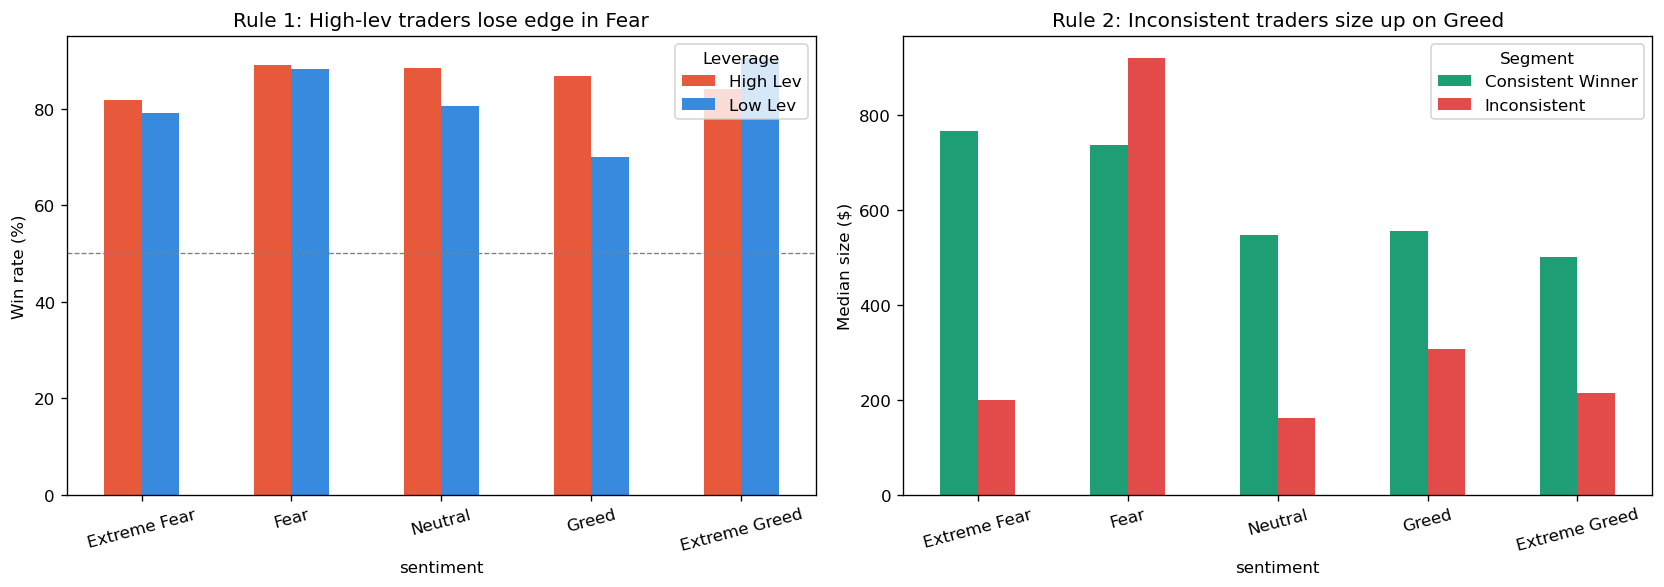

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_rec = ['#1D9E75', '#E24B4A']

# Rule 1 visual
wr_lev = close_df.groupby(['sentiment', 'lev_seg'])['is_win'].mean().unstack().reindex(sent_order) * 100
wr_lev.plot(kind='bar', ax=axes[0], color=['#E8593C', '#378ADD'])
axes[0].axhline(50, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Rule 1: High-lev traders lose edge in Fear')
axes[0].set_ylabel('Win rate (%)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Leverage')

# Rule 2 visual
sizing_comparison.plot(kind='bar', ax=axes[1], color=colors_rec)
axes[1].set_title('Rule 2: Inconsistent traders size up on Greed')
axes[1].set_ylabel('Median size ($)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Segment')

plt.tight_layout()
plt.savefig('fig_recommendations.png', bbox_inches='tight')
plt.show()

---
## Recommendations Summary

| Strategy | Applies To | Action | Evidence |
|---|---|---|---|
| **Rule 1: Contrarian regime sizing** | All traders | Increase size/frequency on Fear; reduce on Greed | Fear daily PnL = 11.7× Greed; traders already long on Fear, short on Greed |
| **Rule 2: Strategy-regime alignment** | Frequent traders | Prioritise Fear-day setups | Frequent WR: 89.1% on Fear vs 74.5% on Greed |
| **Rule 2: Strategy-regime alignment** | Infrequent traders | Prioritise Greed-day setups | Infrequent WR: 91.8% on Greed vs 83.6% on Fear |

**What both rules share:** They ask traders to know their own strategy type and align it to the right regime — not to fight the data. The traders in this sample who perform best are already behaving in a contrarian, fear-embracing way.

**Limitation:** This sample covers 32 high-performing accounts. All have win rates above 77%, indicating strong selection bias. These rules apply to systematic/contrarian traders and may not generalise to retail momentum traders.

**Next:** Notebook 09 — Visualization.
